# Diagramas de Clases UML en Python

Bienvenido/a. En esta lección aprenderás a representar la estructura de tus programas usando diagramas de clases UML y cómo generarlos desde Python.

## Objetivos
- Comprender qué es un diagrama de clases UML y su utilidad.
- Relacionar clases de Python con elementos de UML.
- Generar diagramas de clases usando Graphviz.

---

**Ejemplo de la vida real:** Un diagrama de clases es como el plano arquitectónico de un edificio: muestra cómo se relacionan las partes antes de construirlo.

## Explicación detallada

### Estructura de una clase en UML

En un diagrama de clases, cada clase se representa como un rectángulo dividido en tres secciones:

1. **Nombre de la clase** (parte superior).
2. **Atributos** (parte media): `visibilidad nombre: tipo`.
3. **Métodos** (parte inferior): `visibilidad nombre(parámetros): tipo_retorno`.

La visibilidad se indica con un símbolo antes del nombre:

- `+` público
- `-` privado
- `#` protegido

Por ejemplo, la clase `Professor` de nuestro dominio se representaría así:

```
+----------------------------+
| Professor                  |
+----------------------------+
| - student: Student         |
+----------------------------+
| + teach(course: Course)    |
+----------------------------+
```

### Tipos de relaciones entre clases

UML define varias formas de conectar clases. Las cuatro primeras describen **qué tiene** una clase (relaciones "tiene-un"); las dos últimas describen **qué es** una clase (relaciones "es-un"):

- **Dependencia** (`- - ->`, flecha punteada abierta): una clase usa a otra de forma temporal, típicamente como parámetro de un método, sin guardar una referencia permanente. Si la clase usada cambia su interfaz, la clase dependiente puede romperse, pero no hay una relación estructural duradera entre ambas.

- **Asociación** (`——>`, línea sólida): una clase mantiene una referencia a otra como parte de su estado (un atributo), de forma más o menos permanente. Es una relación estructural, no solo de uso puntual.

- **Agregación** (`◇——`, rombo vacío): un caso especial de asociación donde una clase "tiene" a otra, pero la parte puede existir independientemente del todo (relación todo-parte débil). Por ejemplo, un `Curso` puede tener una lista de `Estudiante`s, pero los estudiantes existen aunque el curso se elimine.

- **Composición** (`◆——`, rombo lleno): una asociación más fuerte donde la parte no puede existir sin el todo (relación todo-parte fuerte). Por ejemplo, una `Casa` está compuesta de `Habitacion`es: si se destruye la casa, las habitaciones dejan de existir como tales.

- **Herencia / Generalización** (`——▷`, línea continua con punta triangular vacía): una subclase **es-un** tipo más específico de su superclase, y hereda sus atributos y métodos ya implementados. Por ejemplo, `Estudiante` y `Profesor` son-un `Persona`: ambos heredan `nombre` y `saludar()` sin tener que reescribirlos.

- **Realización / Implementación** (`- - ▷`, línea punteada con punta triangular vacía): una clase **cumple el contrato** de una interfaz o clase abstracta, implementando sus métodos, pero sin heredar código ya escrito. Por ejemplo, `Estudiante` y `Profesor` implementan `Notificable`, cada una con su propia versión de `notificar()`.

La punta triangular vacía (▷) es lo que distingue a herencia/realización de las demás relaciones: siempre apunta de la subclase/implementación hacia la superclase/interfaz. La única diferencia visual entre ambas es la línea: continua para herencia, punteada para realización — el mismo patrón que distingue asociación de dependencia.

### Aplicando esto al dominio Course-Student-Professor

En `ejemplo_uml.py` (ver también `uml_class_diagram.puml`):

- `Professor` guarda una referencia a `Student` en su atributo `self.student`, inicializada en el constructor y accesible durante toda la vida del objeto. Esto es una **asociación**.

- `Professor.teach()` recibe un objeto `Course` únicamente como parámetro del método, sin guardarlo como atributo. Esto es una **dependencia**: `Professor` depende de la interfaz de `Course` (su método `get_knowledge()`), pero no mantiene una relación estructural con él.

- `Estudiante` y `Profesor` heredan de `Persona` (comparten `nombre` y `saludar()`), y ambas implementan `Notificable` (cada una define su propio `notificar()`). Esto combina **herencia** y **realización** sobre las mismas clases.

Esta distinción importa en la práctica: si cambia la forma de crear un `Course`, solo se ven afectados los lugares donde se *usa* (dependencia); pero si cambiara la forma en que `Professor` accede a `Student`, el impacto sería mayor porque es parte de su estado interno (asociación). Y si cambiara la firma de `Persona.saludar()`, el impacto se propagaría a **todas** las subclases automáticamente (herencia) — por eso modificar una superclase es más delicado que modificar una clase usada por dependencia.

## Ejemplo práctico

A continuación generamos el diagrama de clases correspondiente al dominio `Course`-`Student`-`Professor` usando Graphviz. Este diagrama es una versión simplificada (nodos y relaciones básicas) del diagrama formal que se puede escribir en PlantUML — ver `uml_class_diagram.puml` para la versión con atributos, métodos y visibilidad completos.

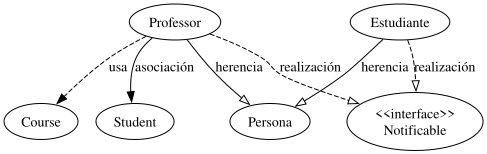

In [1]:
# Diagrama de Clases UML para el ejemplo Course-Student-Professor
# + Herencia (Persona -> Estudiante, Profesor) y Realización (Notificable)

from graphviz import Digraph

dot = Digraph(comment='Diagrama de Clases')

dot.node('Course', 'Course')
dot.node('Student', 'Student')
dot.node('Professor', 'Professor')

# Relaciones "tiene-un"
# Professor -- Student (asociación)
dot.edge('Professor', 'Student', label='asociación')
# Professor -- Course (dependencia)
dot.edge('Professor', 'Course', label='usa', style='dashed')

# Relaciones "es-un": herencia y realización usan punta triangular vacía
dot.node('Persona', 'Persona')
dot.node('Estudiante', 'Estudiante')
dot.node('Notificable', '<<interface>>\nNotificable')

# Herencia: línea continua, punta vacía, apunta a la superclase
dot.edge('Estudiante', 'Persona', label='herencia', arrowhead='empty')
dot.edge('Professor', 'Persona', label='herencia', arrowhead='empty')

# Realización: línea punteada, punta vacía, apunta a la interfaz
dot.edge('Estudiante', 'Notificable', label='realización', style='dashed', arrowhead='empty')
dot.edge('Professor', 'Notificable', label='realización', style='dashed', arrowhead='empty')

# Métodos
# (Opcional: se pueden agregar como notas o en la descripción de los nodos)

# Visualizar el diagrama
# dot.render('uml_class_diagram', view=True)
dot

## Ejercicios prácticos y preguntas de reflexión

1. Modifica el diagrama para agregar una nueva clase `Examen` asociada a `Course`.
2. Agrega al diagrama una clase `Administrativo` que herede de `Persona` (arrowhead='empty') y una interfaz `Auditable` que `Course` implemente (style='dashed', arrowhead='empty').
3. ¿Por qué es útil visualizar la estructura de clases antes de programar?
4. ¿Por qué herencia y realización comparten el mismo símbolo (punta triangular vacía) y solo se distinguen por el tipo de línea?

### Autoevaluación
- ¿Qué elementos de UML se corresponden con atributos y métodos de Python?
- ¿Puedes dar un ejemplo de diagrama de clases en otro contexto (por ejemplo, una tienda online) que use herencia?

## Referencias y recursos
- [Documentación oficial de UML](https://www.uml.org/)
- [Graphviz: documentación y ejemplos](https://graphviz.gitlab.io/documentation/)
- [PlantUML: diagramas UML con texto](https://plantuml.com/es/class-diagram)
- [Visualizador de objetos Python Tutor](https://pythontutor.com/)